In [18]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import os
import psutil # Pastikan sudah install: pip install psutil

# Import dasar untuk SklearnWrapper
from sklearn.base import BaseEstimator, RegressorMixin

# Import model-model yang digunakan dalam base_estimators
from sklearn.ensemble import (StackingRegressor, RandomForestRegressor, 
                              ExtraTreesRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor)
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.svm import SVR

# Import model pihak ketiga (pastikan sudah install: pip install xgboost lightgbm catboost)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [19]:
# 1. LOAD DATA
df = pd.read_excel('feature selected dataset uci.xlsx')
X = df.drop(columns=['feat_127'])
y = df['feat_127']

In [20]:
df

,feat_49,feat_8,feat_33,feat_45,feat_73,feat_54,feat_112,feat_116,feat_124,feat_123,feat_127
0,0.59,0.90,0.19,0.75,0.09,0.04,0.070000,0.57000,0.500000,0.900000,0.20
1,0.47,0.74,0.24,0.91,0.20,0.00,0.134859,0.55605,0.440439,0.698589,0.67
2,0.44,0.56,0.27,0.71,0.15,0.01,0.134859,0.55605,0.440439,0.698589,0.43
3,0.54,0.08,0.10,0.49,0.12,0.03,0.134859,0.55605,0.440439,0.698589,0.12
4,0.91,0.95,0.06,0.20,0.02,0.00,0.134859,0.55605,0.440439,0.698589,0.03
...,...,...,...,...,...,...,...,...,...,...,...
1989,0.68,0.87,0.16,0.59,0.10,0.00,0.134859,0.55605,0.440439,0.698589,0.09
1990,0.63,0.28,0.32,0.56,0.67,0.03,0.134859,0.55605,0.440439,0.698589,0.45
1991,0.42,0.69,0.31,0.50,0.15,0.13,0.340000,0.36000,0.000000,0.780000,0.23
1992,0.65,0.87,0.16,0.30,0.13,0.02,0.040000,0.57000,0.000000,0.790000,0.19


In [21]:
# ==========================================
# 2. SETUP EKSPERIMEN BIG O
# ==========================================
# Kita mencoba dari 10% data hingga 100% data
sample_sizes = np.linspace(0.1, 1.0, 10) 
n_records = []
execution_times = []

print("Memulai pengukuran waktu eksekusi (Empirical Big O)...")
print("-" * 50)





Memulai pengukuran waktu eksekusi (Empirical Big O)...
--------------------------------------------------


In [22]:
# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags


# ==========================================
# 3. LOOPING UNTUK MENGUKUR WAKTU
# ==========================================
  
for prop in sample_sizes:
    n = int(len(df) * prop)
    X_subset = X.iloc[:n]
    y_subset = y.iloc[:n]
    n_records.append(n)

    # ----------------------------------------------------
    # SETUP STACKING REGRESSOR
    # ----------------------------------------------------
    # 1. Definisikan Base Models (Sesuaikan dengan model di notebook Anda)
    # Contoh di bawah ini menggunakan Random Forest dan XGBoost
    base_estimators = [
   ('xgb', SklearnWrapper(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))),
    ('cat', SklearnWrapper(CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42))),
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, verbosity=-1, random_state=42))),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('svr', SklearnWrapper(SVR(C=1.0, epsilon=0.1))),
    ('lasso', Lasso(alpha=0.01))
    ]
    
    # 2. Definisikan Final Estimator (Meta-model)
    final_estimator = RidgeCV()
    
    # 3. Gabungkan ke dalam StackingRegressor
    model = StackingRegressor(
        estimators=base_estimators,
        final_estimator=final_estimator,
        cv=5 # Menggunakan 5-fold cross validation saat melatih meta-model
    )
    # ----------------------------------------------------
    



    # Mulai timer
    start_time = time.time()
    
    # Jalankan proses (Training Model)
    model.fit(X_subset, y_subset)
    
    # Hentikan timer
    end_time = time.time()
    
    # Hitung selisih
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    
    print(f"Ukuran Data (N) = {n:<6} | Waktu = {elapsed_time:.4f} detik")

Ukuran Data (N) = 199    | Waktu = 5.6827 detik
Ukuran Data (N) = 398    | Waktu = 5.9868 detik
Ukuran Data (N) = 598    | Waktu = 7.9863 detik
Ukuran Data (N) = 797    | Waktu = 9.3740 detik
Ukuran Data (N) = 997    | Waktu = 10.1117 detik
Ukuran Data (N) = 1196   | Waktu = 13.2614 detik
Ukuran Data (N) = 1395   | Waktu = 13.7256 detik
Ukuran Data (N) = 1595   | Waktu = 17.2465 detik
Ukuran Data (N) = 1794   | Waktu = 15.6049 detik
Ukuran Data (N) = 1994   | Waktu = 17.3690 detik


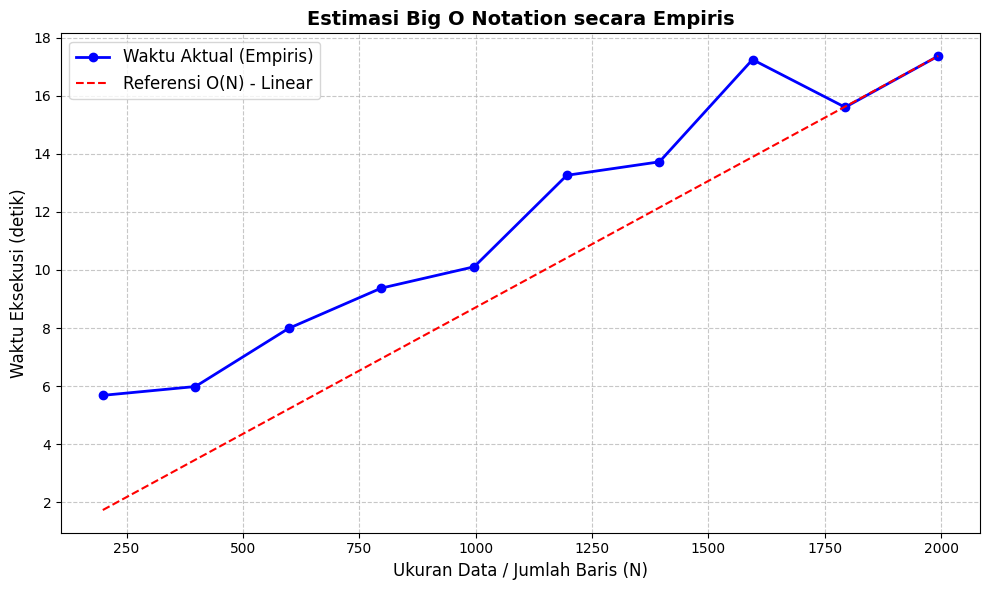

In [23]:
# ==========================================
# 4. VISUALISASI KURVA BIG O
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(n_records, execution_times, marker='o', linestyle='-', color='blue', linewidth=2, label='Waktu Aktual (Empiris)')

# Membuat garis referensi O(N) linear untuk perbandingan
time_linear = [execution_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, time_linear, linestyle='--', color='red', label='Referensi O(N) - Linear')

plt.title('Estimasi Big O Notation secara Empiris', fontsize=14, fontweight='bold')
plt.xlabel('Ukuran Data / Jumlah Baris (N)', fontsize=12)
plt.ylabel('Waktu Eksekusi (detik)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()